In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
import numpy as np
%matplotlib inline

# Commentaire

Test pour détecter la langue

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
data=pd.read_csv("https://raw.githubusercontent.com/nikhil-iyer-97/Language-Identifier/master/data/dataset.csv", names=["language", "Text"])

In [ ]:
data.head()

,language,Text
0,lang,sentences
1,deu,Lass uns etwas versuchen!
2,deu,Ich muss schlafen gehen.
3,deu,Was ist das?
4,deu,Heute ist der 18. Juni und das ist der Geburts...


In [ ]:
data.shape

(361864, 2)

In [ ]:
data.isnull().sum()

language    0
Text        0
dtype: int64

In [ ]:
data["language"].value_counts()

jpn     25000
cmn     24992
eng     24981
pol     24980
deu     24974
ita     24974
fra     24973
spa     24973
rus     24956
por     24952
heb     22468
nld     18332
hun     15918
ukr     14751
ara      7347
isl      6208
lat      4905
dan      3992
fin      3956
bul      3606
hin      2754
swe      2400
ind      1486
hrv      1243
kor       733
kaz       707
urd       669
mal       284
afr       242
tha       107
lang        1
Name: language, dtype: int64

In [ ]:
language_counts = data.groupby('language')['language'].transform('count')

# Filter the DataFrame based on the condition (count >= 15000)
df_filtered = data[language_counts >= 15000]

sample_size_per_category = 1000
random_sample_df = df_filtered.groupby(
    'language', group_keys=False
    ).apply(
        lambda group: group.sample(
            n=min(sample_size_per_category, len(group)),
            random_state=42
            )
    )

languages_to_drop = ["cmn", "heb", "jpn", "rus"]

mask = ~random_sample_df['language'].isin(languages_to_drop)

df = random_sample_df[mask]

In [ ]:
df["language"].value_counts()

deu    1000
eng    1000
fra    1000
hun    1000
ita    1000
nld    1000
pol    1000
por    1000
spa    1000
Name: language, dtype: int64

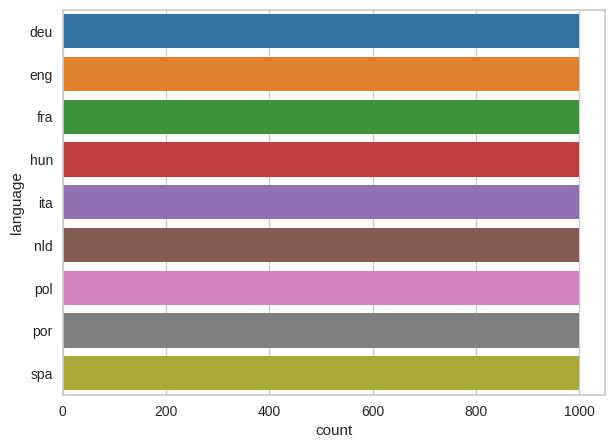

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(y="language",data=df,palette="tab10")
plt.show()

In [ ]:
df = df.drop_duplicates(subset='Text')
df = df.reset_index(drop=True)

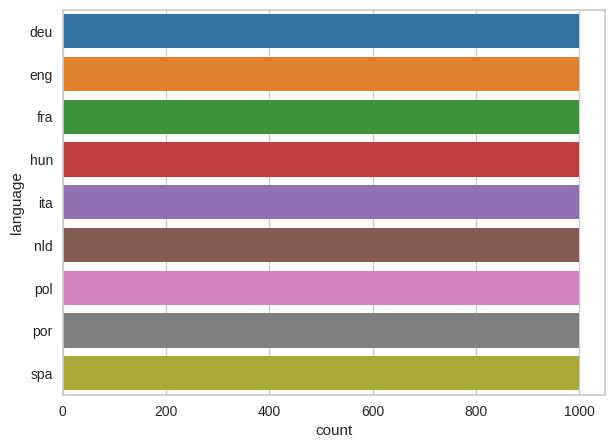

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(y="language",data=df,palette="tab10")
plt.show()

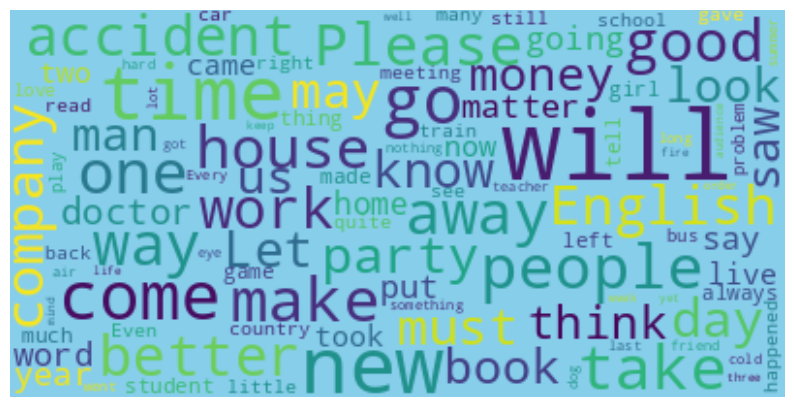

In [ ]:
english_text_df = df[df['language'] == 'eng']
stopwords = set(STOPWORDS)
text2 = "  ".join(review for review in english_text_df['Text'])
wordcloud = WordCloud(max_font_size=50, max_words=100,
                      background_color="skyblue",
                      stopwords=stopwords).generate(text2)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

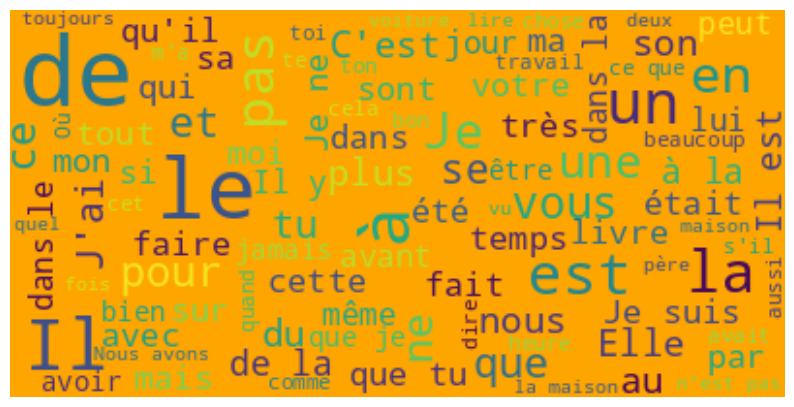

In [ ]:
swedish_text_df = df[df['language'] == 'fra']
text2 = "  ".join(review for review in swedish_text_df['Text'])
# Assuming 'text' is the column containing the fra text
wordcloud = WordCloud(max_font_size=50, max_words=100,
                      background_color="orange",
                      stopwords=stopwords).generate(text2)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


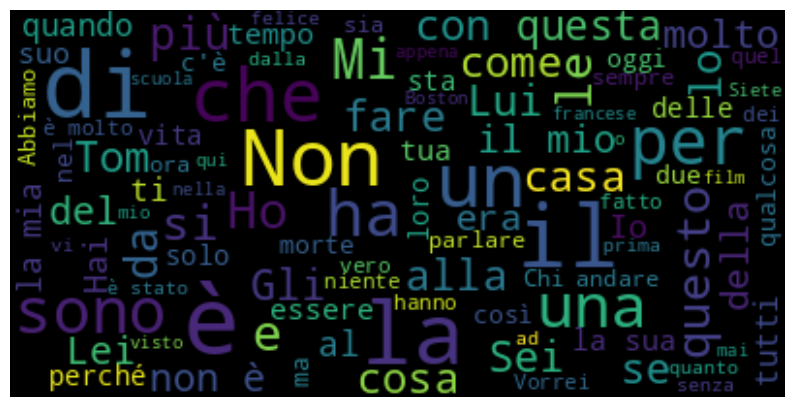

In [ ]:
dutch_text_df = df[df['language'] == 'ita']
text2 = "  ".join(review for review in dutch_text_df['Text'])
wordcloud = WordCloud(max_font_size=50, max_words=100,
                      background_color="black",
                      stopwords=stopwords).generate(text2)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()



In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["language"]=le.fit_transform(df["language"])

In [ ]:
df["language"].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
# decoded_languages = le.inverse_transform(df["language"])
# df["decoded_language"] = decoded_languages

# print(df[["decoded_language", "language"]])


In [ ]:
decoded_languages = le.inverse_transform(df["language"])
df["decoded_language"] = decoded_languages
unique_decoded_languages = sorted(df["decoded_language"].unique())
unique_languages = sorted(df["language"].unique())

print("======================================================================================================================")
print("Unique Decoded Languages (Ascending Order):", unique_decoded_languages)
print("======================================================================================================================")
print("Unique Languages (Ascending Order):", unique_languages)
print("======================================================================================================================")

Unique Decoded Languages (Ascending Order): ['deu', 'eng', 'fra', 'hun', 'ita', 'nld', 'pol', 'por', 'spa']
Unique Languages (Ascending Order): [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
df.tail()

,language,Text,decoded_language
8995,8,"Como los buenos vinos, él mejora con la edad.",spa
8996,8,Espere la señal verde antes de empezar a atrav...,spa
8997,8,Llevo cinco años estudiando japonés.,spa
8998,8,Soy intolerante a la lactosa de la leche.,spa
8999,8,Los resultados del estudio son indeterminados.,spa


In [ ]:
total_length = sum(len(text) for text in df["Text"])
num_texts = len(df["Text"])
average_length = total_length / num_texts
print("Average text length:", average_length)

Average text length: 39.214666666666666


# Nettoyage des données

In [ ]:
from nltk.corpus import stopwords
import re
import unicodedata
from bs4 import BeautifulSoup


def clean_text(text):

    # Remove HTML tags if present
    if "<" in text:
        text = BeautifulSoup(text, 'html.parser').get_text()

    # Remove URL addresses
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove accented characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)

    # Remove irrelevant characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    text = ' '.join(filtered_words)

    return text

In [ ]:
df["Text"] = df["Text"].apply(clean_text)

In [ ]:
df.tail()

,language,Text,decoded_language
8995,8,Como los buenos vinos el mejora con la edad,spa
8996,8,Espere la senal verde antes de empezar atravesar,spa
8997,8,Llevo cinco anos estudiando japones,spa
8998,8,Soy intolerante la lactosa de la leche,spa
8999,8,Los resultados del estudio son indeterminados,spa


In [ ]:
X=df["Text"]
Y=df["language"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
tf= TfidfVectorizer()
train_data=tf.fit_transform(X)
print(train_data)

  (0, 8203)	0.5233935052464744
  (0, 14419)	0.4831126423617246
  (0, 10213)	0.3673265459564965
  (0, 15051)	0.5233935052464744
  (0, 4886)	0.2894682379079947
  (1, 10882)	0.5458734158845374
  (1, 1751)	0.6936045235699195
  (1, 7376)	0.4700372099248016
  (2, 15921)	0.4955705293680282
  (2, 18658)	0.41637579031108773
  (2, 801)	0.4590739965365704
  (2, 3681)	0.31827106648475667
  (2, 14265)	0.4590739965365704
  (2, 14602)	0.2413435545260055
  (3, 6494)	0.26447261876497885
  (3, 8404)	0.3423051858658597
  (3, 4175)	0.3275587304654636
  (3, 7939)	0.3423051858658597
  (3, 1518)	0.3423051858658597
  (3, 4989)	0.1635022254787051
  (3, 17805)	0.3023494984510758
  (3, 4928)	0.3423051858658597
  (3, 10186)	0.22047174019876267
  (3, 8544)	0.27714026643668793
  (3, 18658)	0.28760304305067963
  :	:
  (8996, 1075)	0.4246723514654341
  (8996, 4714)	0.4246723514654341
  (8996, 14453)	0.4246723514654341
  (8996, 741)	0.33375876085693706
  (8996, 17198)	0.3933971494520382
  (8996, 5069)	0.37510232907172

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(train_data,Y,test_size=0.3,random_state=42)

In [ ]:
svm= SVC()
svm.fit(X_train, Y_train)

SVC()

In [ ]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 90.11%


![](https://static.packt-cdn.com/products/9781838555078/graphics/C13314_06_05.jpg)

# Matrice de confusion

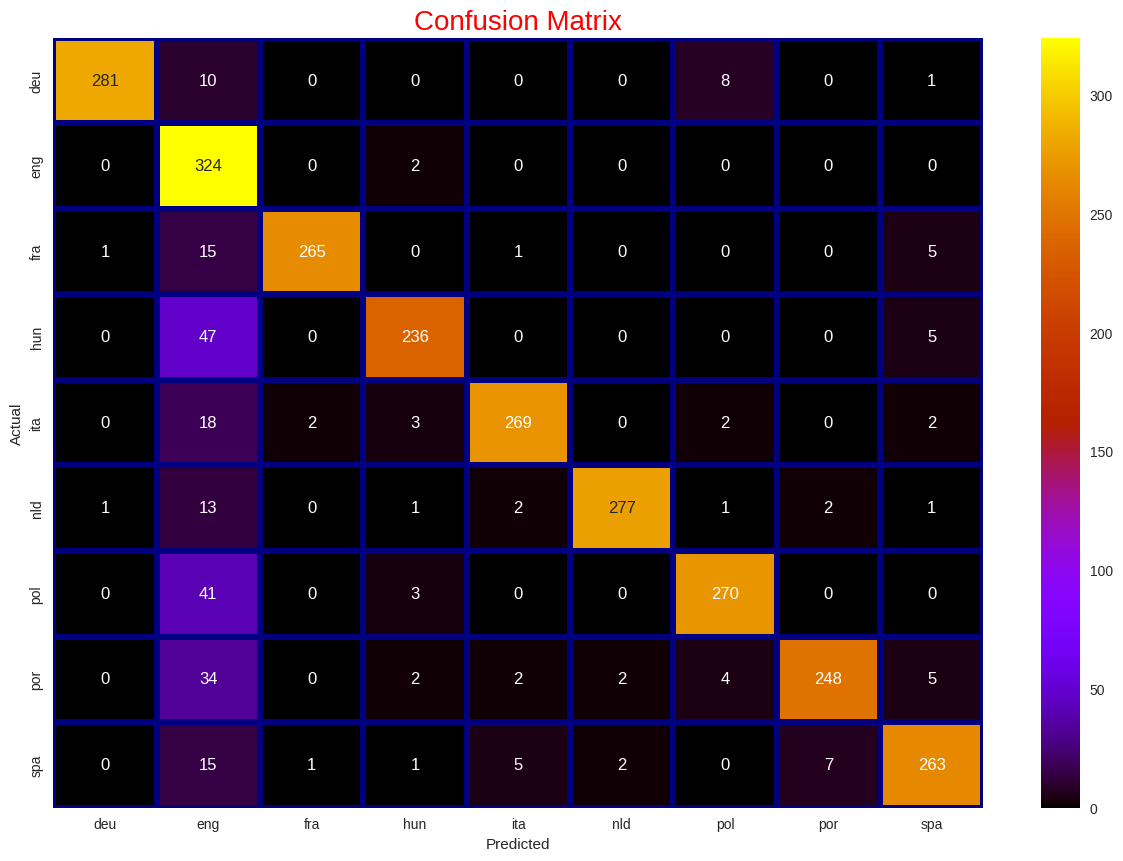

In [ ]:
cf=confusion_matrix(Y_test,y_pred)
label_name=unique_decoded_languages
plt.figure(figsize=(15,10))
sns.heatmap(cf,annot=True,fmt="d",xticklabels=label_name,yticklabels=label_name,cmap="gnuplot",
           linewidths=3, linecolor='navy')
plt.title("Confusion Matrix",fontsize=20,color="red")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Rapport de classement

In [ ]:
print(classification_report(Y_test,y_pred,target_names=label_name))

              precision    recall  f1-score   support

         deu       0.99      0.94      0.96       300
         eng       0.63      0.99      0.77       326
         fra       0.99      0.92      0.95       287
         hun       0.95      0.82      0.88       288
         ita       0.96      0.91      0.94       296
         nld       0.99      0.93      0.96       298
         pol       0.95      0.86      0.90       314
         por       0.96      0.84      0.90       297
         spa       0.93      0.89      0.91       294

    accuracy                           0.90      2700
   macro avg       0.93      0.90      0.91      2700
weighted avg       0.92      0.90      0.91      2700



#Roc Auc

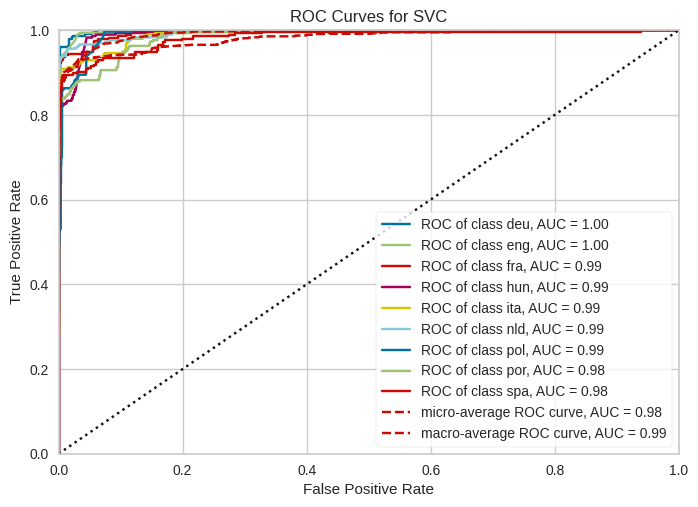

<Figure size 2000x1500 with 0 Axes>

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
from yellowbrick.classifier import ROCAUC


model = SVC()
visualizer = ROCAUC(model, classes=label_name)

visualizer.fit(X_train, Y_train)
visualizer.score(X_test, Y_test)
plt.figure(figsize=(20, 15))

visualizer.show()


# Bayes naïf

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nb= MultinomialNB()
nb.fit(X_train,Y_train)

MultinomialNB()

In [ ]:
pred1=nb.predict(X_test)
accuracy1 = accuracy_score(Y_test,pred1)
print(f"Accuracy: {accuracy1 * 100:.2f}%")

Accuracy: 95.33%


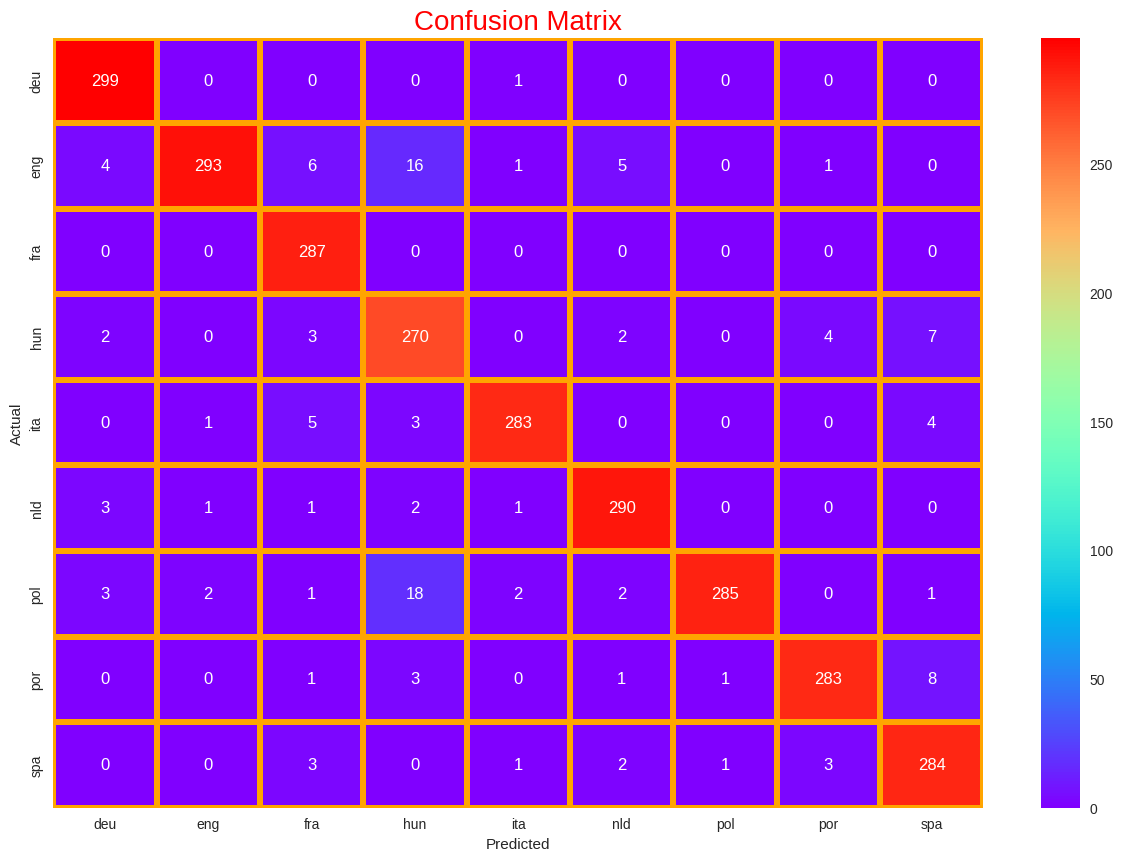

In [ ]:
cf0=confusion_matrix(Y_test,pred1)
label_name=unique_decoded_languages
plt.figure(figsize=(15,10))
sns.heatmap(cf0,annot=True,fmt="d",xticklabels=label_name,yticklabels=label_name,cmap="rainbow",
           linewidths=3, linecolor='orange')
plt.title("Confusion Matrix",fontsize=20,color="red")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(Y_test,pred1,target_names=label_name))

              precision    recall  f1-score   support

         deu       0.96      1.00      0.98       300
         eng       0.99      0.90      0.94       326
         fra       0.93      1.00      0.97       287
         hun       0.87      0.94      0.90       288
         ita       0.98      0.96      0.97       296
         nld       0.96      0.97      0.97       298
         pol       0.99      0.91      0.95       314
         por       0.97      0.95      0.96       297
         spa       0.93      0.97      0.95       294

    accuracy                           0.95      2700
   macro avg       0.95      0.95      0.95      2700
weighted avg       0.96      0.95      0.95      2700



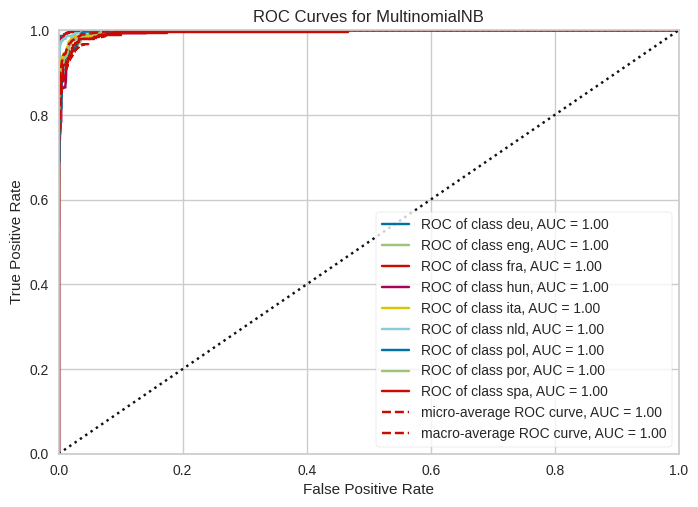

<Figure size 2000x1500 with 0 Axes>

<Axes: title={'center': 'ROC Curves for MultinomialNB'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
model = MultinomialNB()
visualizer = ROCAUC(model, classes=label_name)

visualizer.fit(X_train, Y_train)
visualizer.score(X_test, Y_test)
plt.figure(figsize=(20, 15))

visualizer.show()

# CountVectorizer

In [ ]:
import numpy as np
X_data=df["Text"]
Y_data=df["language"]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
new_data=vectorizer.fit_transform(X_data)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(new_data,Y_data,test_size=0.3,random_state=42)

In [ ]:
new_svm = SVC()
new_svm.fit(x_train, y_train)

SVC()

In [ ]:
new_pred= new_svm.predict(x_test)
new_accuracy = accuracy_score(y_test,new_pred)
print(f"Accuracy: {new_accuracy * 100:.2f}%")

Accuracy: 84.85%


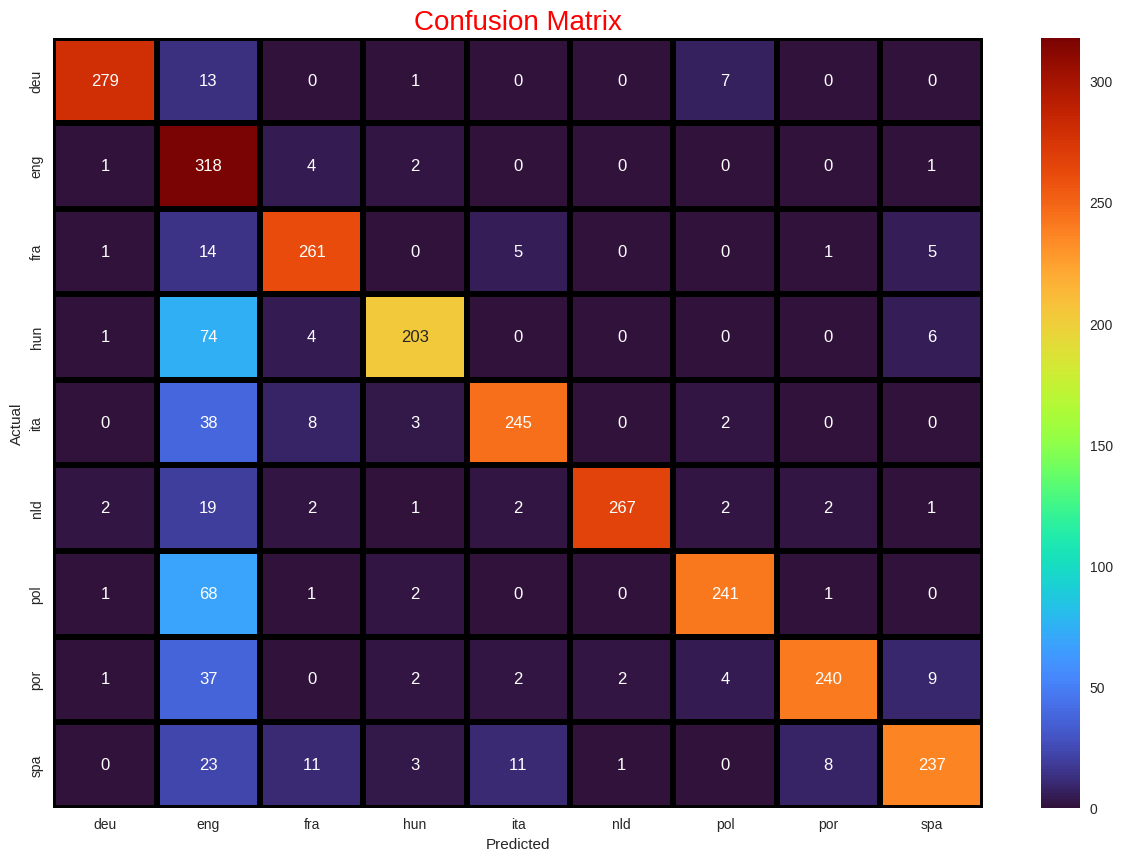

In [ ]:
cf2=confusion_matrix(y_test,new_pred)
label_name=unique_decoded_languages
plt.figure(figsize=(15,10))
sns.heatmap(cf2,annot=True,fmt="d",xticklabels=label_name,yticklabels=label_name,cmap="turbo",
           linewidths=3, linecolor='black')
plt.title("Confusion Matrix",fontsize=20,color="red")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test,new_pred,target_names=label_name))

              precision    recall  f1-score   support

         deu       0.98      0.93      0.95       300
         eng       0.53      0.98      0.68       326
         fra       0.90      0.91      0.90       287
         hun       0.94      0.70      0.80       288
         ita       0.92      0.83      0.87       296
         nld       0.99      0.90      0.94       298
         pol       0.94      0.77      0.85       314
         por       0.95      0.81      0.87       297
         spa       0.92      0.81      0.86       294

    accuracy                           0.85      2700
   macro avg       0.90      0.85      0.86      2700
weighted avg       0.89      0.85      0.86      2700



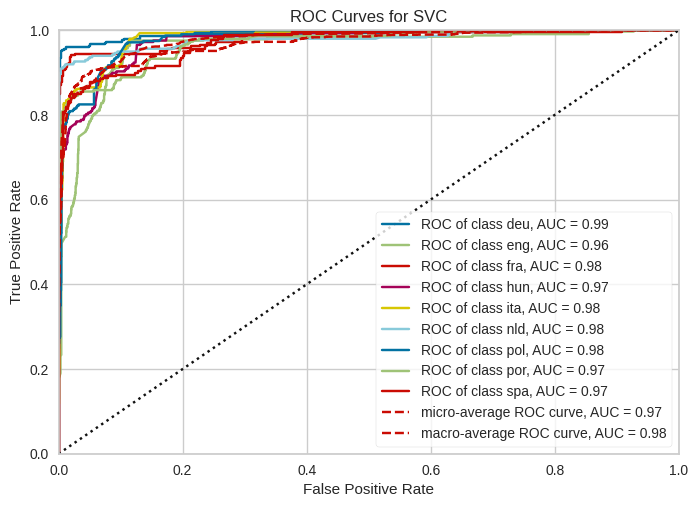

<Figure size 2000x1500 with 0 Axes>

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
new_model = SVC()
visualizer = ROCAUC(new_model, classes=label_name)

visualizer.fit(x_train, y_train)
visualizer.score(x_test, y_test)
plt.figure(figsize=(20, 15))

visualizer.show()

# Bayes naïf+Countvectorizer

In [ ]:
new_nb= MultinomialNB()
new_nb.fit(x_train,y_train)

MultinomialNB()

In [ ]:
pred3=nb.predict(x_test)
accuracy1 = accuracy_score(y_test,pred3)
print(f"Accuracy: {accuracy1 * 100:.2f}%")

Accuracy: 94.81%


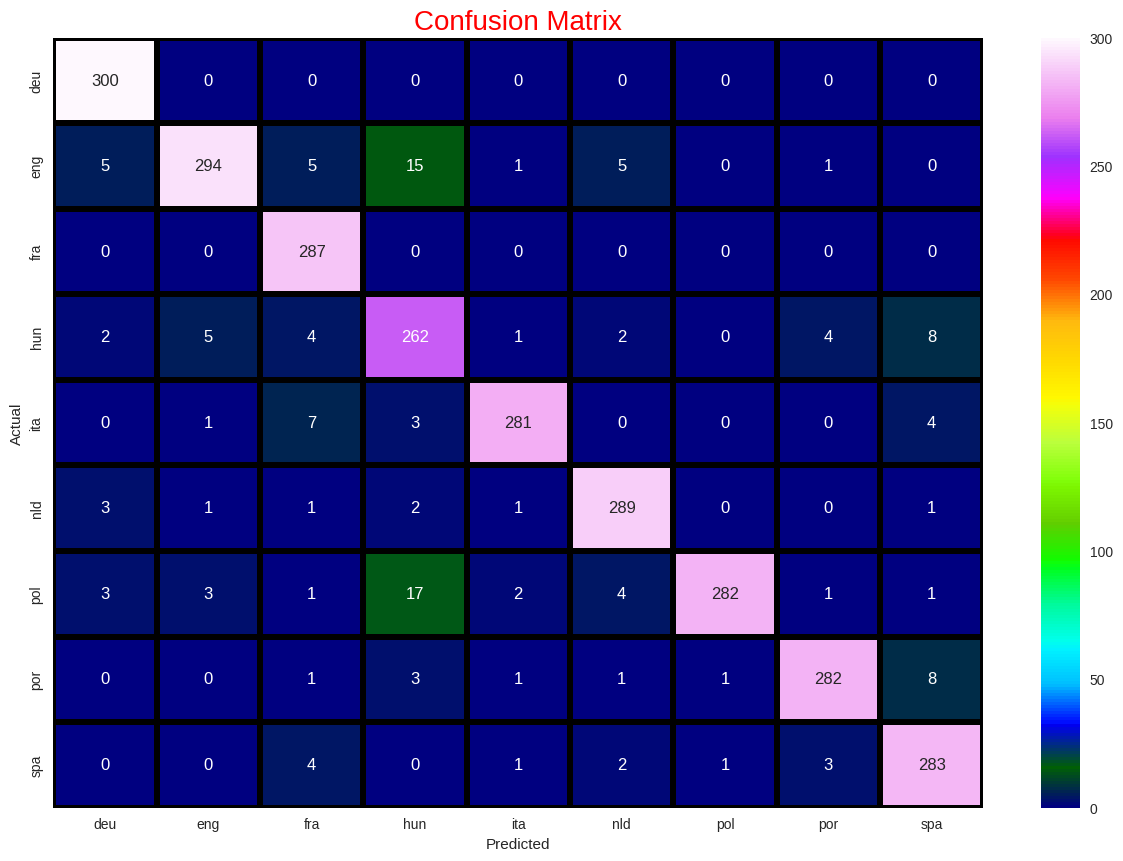

In [ ]:
cf4=confusion_matrix(y_test,pred3)
label_name=unique_decoded_languages
plt.figure(figsize=(15,10))
sns.heatmap(cf4,annot=True,fmt="d",xticklabels=label_name,yticklabels=label_name,cmap="gist_ncar",
           linewidths=3, linecolor='black')
plt.title("Confusion Matrix",fontsize=20,color="red")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test,pred3,target_names=label_name))

              precision    recall  f1-score   support

         deu       0.96      1.00      0.98       300
         eng       0.97      0.90      0.93       326
         fra       0.93      1.00      0.96       287
         hun       0.87      0.91      0.89       288
         ita       0.98      0.95      0.96       296
         nld       0.95      0.97      0.96       298
         pol       0.99      0.90      0.94       314
         por       0.97      0.95      0.96       297
         spa       0.93      0.96      0.94       294

    accuracy                           0.95      2700
   macro avg       0.95      0.95      0.95      2700
weighted avg       0.95      0.95      0.95      2700



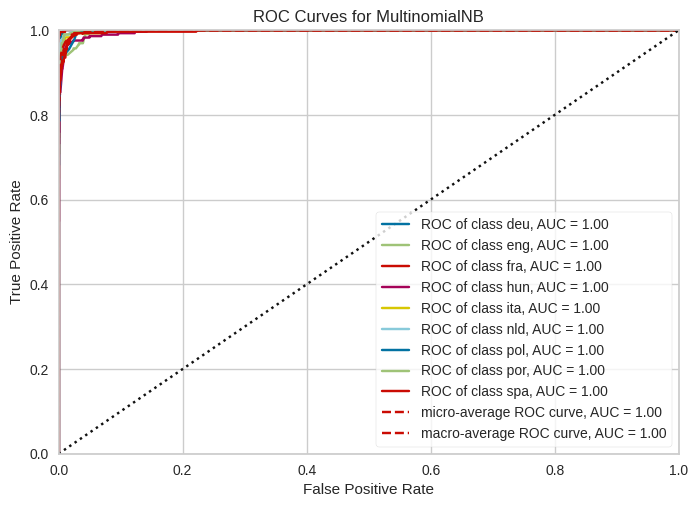

<Figure size 2000x1500 with 0 Axes>

<Axes: title={'center': 'ROC Curves for MultinomialNB'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
new_mo = MultinomialNB()
visualizer = ROCAUC(new_mo, classes=label_name)

visualizer.fit(x_train, y_train)
visualizer.score(x_test, y_test)
plt.figure(figsize=(20, 15))

visualizer.show()